In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
telco_churn_data = pd.read_csv('Telco_Customer_Churn.csv')
telco_churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
telco_churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
telco_churn_data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Data Preprocessing and Feature Engineering

#### Drop duplicates

In [5]:
telco_churn_data.drop_duplicates(inplace=True)
   

In [6]:
telco_churn_data.drop(['customerID'], axis=1, inplace=True)

In [7]:
print(telco_churn_data['StreamingTV'].value_counts())
print(telco_churn_data['StreamingMovies'].value_counts())

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


#### Convert `MonthlyCharges` to numeric datatype

In [8]:
telco_churn_data['MonthlyCharges'] = pd.to_numeric(telco_churn_data['MonthlyCharges'], errors='coerce')
telco_churn_data['StreamingTV'] = telco_churn_data['StreamingTV'].replace({'No internet service': 'No'}).map({'Yes': 1, 'No': 0})
telco_churn_data['StreamingMovies'] = telco_churn_data['StreamingMovies'].replace({'No internet service': 'No'}).map({'Yes': 1, 'No': 0})

telco_churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [9]:
telco_churn_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [38]:
telco_churn_data['Churn'] = telco_churn_data['Churn'].replace({'Yes': 1, 'No': 0})

In [39]:
telco_churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,0.0,0.0,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,0.0,0.0,One year,No,Mailed check,56.95,1889.5,0
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,0.0,0.0,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,0.0,0.0,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,0.0,0.0,Month-to-month,Yes,Electronic check,70.70,151.65,1


#### Check Collinearity

<Axes: >

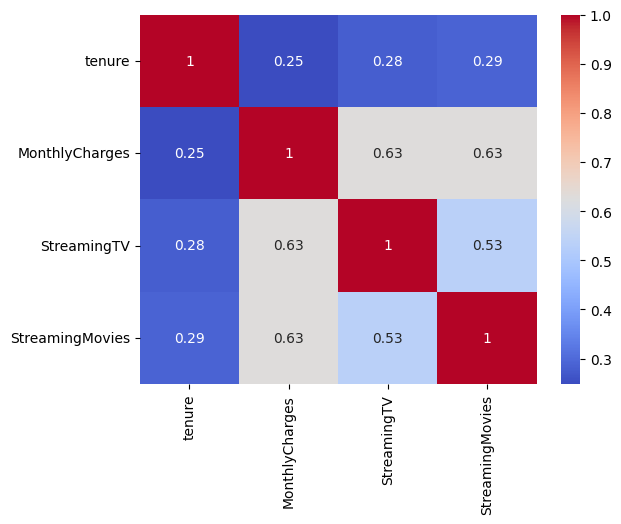

In [40]:
sns.heatmap(telco_churn_data[['tenure', 'MonthlyCharges', 'StreamingTV', 'StreamingMovies']].corr(), annot=True, cmap='coolwarm')

#### Hypothesis Testing -- Chi-Square Test

In [41]:
# chi-square test for categorical variables
from scipy.stats import chi2_contingency

feature_list = telco_churn_data.columns

print(feature_list)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [42]:
churn_affector = []
for feature in feature_list:
    if telco_churn_data[feature].dtype == 'str':
        contingency_table = pd.crosstab(telco_churn_data[feature], telco_churn_data['Churn'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        if p <= 0.05:
            churn_affector.append(feature)
        else:
            print(f"{feature} is not significantly associated with churn (p={p:.4f})\n")

print("Features significantly associated with churn:", churn_affector)

Features significantly associated with churn: []


### Exploratory Data Analysis

#### Demographics
1. Gender
2. Age (Senior or not)
3. Pairplot

<Axes: xlabel='gender'>

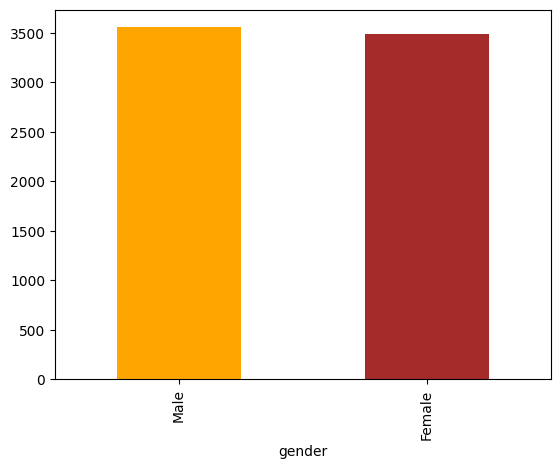

In [43]:
# Gender based analysis with bar plot
telco_churn_data['gender'].value_counts().plot(kind='bar', color=['orange', 'brown'])

In [44]:
churn_affector

[]

In [75]:
important_features = ['Contract', 'InternetService','tenure', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges']

In [76]:
important_features

['Contract',
 'InternetService',
 'tenure',
 'StreamingTV',
 'StreamingMovies',
 'MonthlyCharges']

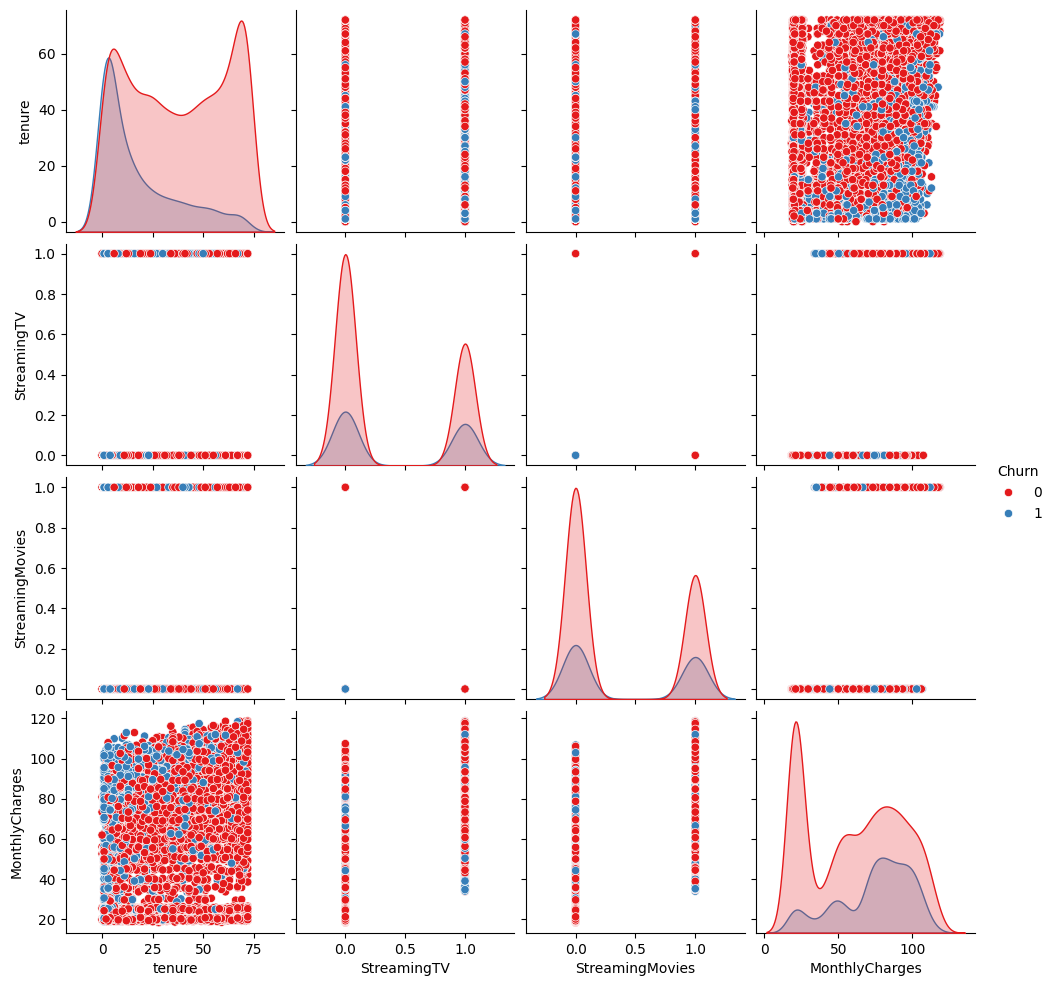

In [77]:
sns.pairplot(telco_churn_data[important_features + ['Churn']], hue='Churn', palette='Set1')

In [78]:
telco_churn_data.dropna(inplace=True)

In [79]:
X = telco_churn_data[important_features]
y = telco_churn_data['Churn']

In [80]:
X.head()

,Contract,InternetService,tenure,StreamingTV,StreamingMovies,MonthlyCharges
0,Month-to-month,DSL,1.0,0.0,0.0,29.85
1,One year,DSL,34.0,0.0,0.0,56.95
2,Month-to-month,DSL,2.0,0.0,0.0,53.85
3,One year,DSL,45.0,0.0,0.0,42.30
4,Month-to-month,Fiber optic,2.0,0.0,0.0,70.70


In [82]:
# Label Encoding for categorical features
from sklearn.preprocessing import LabelEncoder

contract_label_encoder = LabelEncoder()
internet_service_label_encoder = LabelEncoder()

X['Contract_encoded'] = contract_label_encoder.fit_transform(X['Contract'])
X['InternetService_encoded'] = internet_service_label_encoder.fit_transform(X['InternetService'])

In [83]:
X.head()

,Contract,InternetService,tenure,StreamingTV,StreamingMovies,MonthlyCharges,Contract_encoded,InternetService_encoded
0,Month-to-month,DSL,1.0,0.0,0.0,29.85,0,0
1,One year,DSL,34.0,0.0,0.0,56.95,1,0
2,Month-to-month,DSL,2.0,0.0,0.0,53.85,0,0
3,One year,DSL,45.0,0.0,0.0,42.30,1,0
4,Month-to-month,Fiber optic,2.0,0.0,0.0,70.70,0,1


In [84]:
X = X.drop(['Contract', 'InternetService'], axis=1)

In [85]:
X.head()

,tenure,StreamingTV,StreamingMovies,MonthlyCharges,Contract_encoded,InternetService_encoded
0,1.0,0.0,0.0,29.85,0,0
1,34.0,0.0,0.0,56.95,1,0
2,2.0,0.0,0.0,53.85,0,0
3,45.0,0.0,0.0,42.30,1,0
4,2.0,0.0,0.0,70.70,0,1


In [86]:
X.Contract_encoded.value_counts()

Contract_encoded
0    3875
2    1695
1    1473
Name: count, dtype: int64

In [87]:
y.isna().sum()

np.int64(0)

In [88]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

Data is very skewed

#### Rebalancing the data

In [89]:
# %pip install imblearn

In [90]:
y = y.astype(int)

from imblearn.over_sampling import RandomOverSampler

print("Original class distribution:\n", y.value_counts())

print(f'\n Class distribution ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}')

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

print("Resampled class distribution:\n")
print(y_resampled.value_counts())

Original class distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64

 Class distribution ratio: 2.77
Resampled class distribution:

Churn
0    5174
1    5174
Name: count, dtype: int64


### Model Training

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [92]:
def train_model(model, X_train, Y_train):
    model.fit(X_train, Y_train)
    return model

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC

log_model = train_model(LogisticRegression(max_iter=1000, random_state=42), X_train, y_train)
ada_model = train_model(AdaBoostClassifier(n_estimators=100, random_state=42), X_train, y_train)
svm_model = train_model(SVC(probability=True, random_state=42), X_train, y_train)
rf_model = train_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train)

### Model Evaluation

In [94]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name=None):
    """Print classification report, accuracy, ROC AUC (if available) and plot confusion matrix."""
    y_pred = model.predict(X_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    acc = np.mean(y_pred == y_test.values)
    print(f"Accuracy: {acc:.4f}\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.71      0.75      1021
           1       0.74      0.81      0.77      1049

    accuracy                           0.76      2070
   macro avg       0.76      0.76      0.76      2070
weighted avg       0.76      0.76      0.76      2070

Accuracy: 0.7599



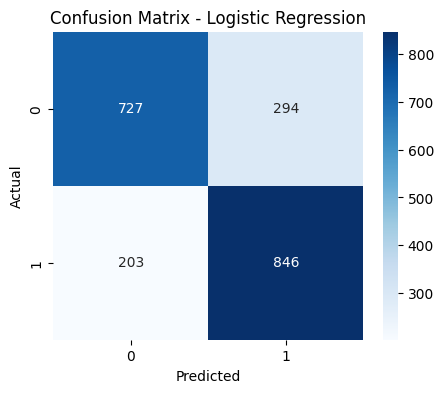

In [95]:
evaluate_model(log_model, X_test, y_test, model_name='Logistic Regression')

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1021
           1       0.75      0.82      0.79      1049

    accuracy                           0.77      2070
   macro avg       0.78      0.77      0.77      2070
weighted avg       0.78      0.77      0.77      2070

Accuracy: 0.7734



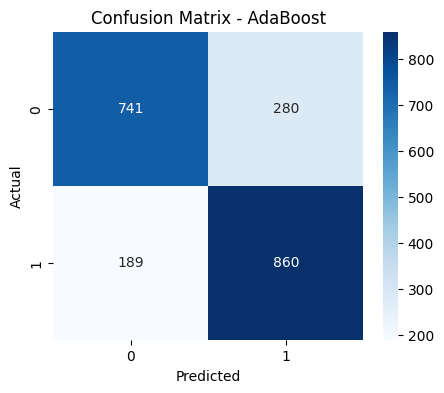

In [96]:
evaluate_model(ada_model, X_test, y_test, model_name='AdaBoost')   

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1021
           1       0.74      0.76      0.75      1049

    accuracy                           0.74      2070
   macro avg       0.74      0.74      0.74      2070
weighted avg       0.74      0.74      0.74      2070

Accuracy: 0.7425



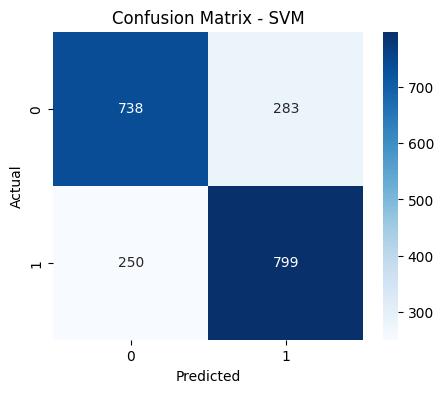

In [97]:
evaluate_model(svm_model, X_test, y_test, model_name='SVM')

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1021
           1       0.83      0.92      0.88      1049

    accuracy                           0.87      2070
   macro avg       0.87      0.87      0.87      2070
weighted avg       0.87      0.87      0.87      2070

Accuracy: 0.8676



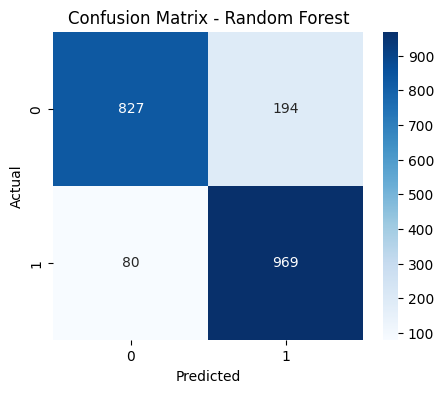

In [98]:
evaluate_model(rf_model, X_test, y_test, model_name='Random Forest')

**Random Forest** Model has predicted the best results with an accuracy of 0.877 so we choose this model for our final model. We can further tune the hyperparameters of this model to improve the performance.

#### Saving models (Encoder, Predictor)

In [99]:
import pickle


with open('./models/churn_predictor.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('./models/contract_encoder.pkl', 'wb') as f:
    pickle.dump(contract_label_encoder, f)

with open('./models/internet_service_encoder.pkl', 'wb') as f:
    pickle.dump(internet_service_label_encoder, f)

### Deployment via Streamlit

### TEST

In [100]:
model = pickle.load(open('./models/churn_predictor.pkl', 'rb'))
encoder = pickle.load(open('./models/contract_encoder.pkl', 'rb'))

In [104]:
encoder.transform(['Month-to-month', 'One year', 'Two year'])

array([0, 1, 2])